In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# device and reproducibility
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# create toy dataset
# (noisy sine-wave sequence) with model predicting next time step
# TODO: later make Gaussian bump


def make_sine_data(n_sequences=512, seq_len=50, input_size=1, noise_std=0.05):
    """
    Returns:
        x: (n_sequences, seq_len, input_size)
        y: (n_sequences, seq_len, input_size)
    where y[t] = x[t+1] (next-step prediction)
    """
    xs = []
    ys = []

    for _ in range(n_sequences):
        # random frequency and phase for each sequence
        phase = np.random.uniform(0, 2 * np.pi)
        freq = np.random.uniform(0.8, 1.2)

        t = np.linspace(0, 2 * np.pi * freq, seq_len + 1)
        signal = np.sin(t + phase)
        signal += np.random.normal(scale=noise_std, size=signal.shape)  # add noise

        x_seq = signal[:-1].reshape(seq_len, input_size)
        y_seq = signal[1:].reshape(seq_len, input_size)

        xs.append(x_seq)
        ys.append(y_seq)

    x = torch.tensor(np.stack(xs), dtype=torch.float32)
    y = torch.tensor(np.stack(ys), dtype=torch.float32)
    return x, y


x_data, y_data = make_sine_data(n_sequences=512, seq_len=50, input_size=1)

print("x_data shape:", x_data.shape)
print("y_data shape:", y_data.shape)

x_data shape: torch.Size([512, 50, 1])
y_data shape: torch.Size([512, 50, 1])


In [4]:
# Train/validation split
n_train = int(0.8 * len(x_data))

x_train = x_data[:n_train]
y_train = y_data[:n_train]

x_val = x_data[n_train:]
y_val = y_data[n_train:]

print("Train:", x_train.shape, y_train.shape)
print("Val: ", x_val.shape, y_val.shape)

Train: torch.Size([409, 50, 1]) torch.Size([409, 50, 1])
Val:  torch.Size([103, 50, 1]) torch.Size([103, 50, 1])


In [5]:
# DataLoader
train_dataset = torch.utils.data.TensorDataset(x_train, y_train)
val_dataset = torch.utils.data.TensorDataset(x_val, y_val)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
class MultiModuleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_modules, output_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_modules = num_modules
        self.output_size = output_size

        # Input for each module
        self.in_linears = nn.ModuleList(
            [nn.Linear(input_size, hidden_size) for _ in range(num_modules)]
        )

        # Self recurrence within each module (hidden_size x hidden_size)
        self.self_linears = nn.ModuleList(
            [
                nn.Linear(hidden_size, hidden_size, bias=False)
                for _ in range(num_modules)
            ]
        )

        # Cross-module recurrence: from module j into module i
        self.cross_linears = nn.ModuleList(
            [
                nn.ModuleList(
                    [
                        nn.Linear(hidden_size, hidden_size, bias=False)
                        for _ in range(num_modules)
                    ]
                )
                for _ in range(num_modules)
            ]
        )

        # Readout from concatenated hidden states
        self.readout = nn.Linear(num_modules * hidden_size, output_size)

        self.reset_parameters()

    def reset_parameters(self):
        # Default initialization is okay but can make cross-module weights smaller so modules start somewhat separate
        for layer in self.in_linears:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

        for layer in self.self_linears:
            nn.init.xavier_uniform_(layer.weight)

        for i in range(self.num_modules):
            for j in range(self.num_modules):
                nn.init.xavier_uniform_(self.cross_linears[i][j].weight)
                if i != j:
                    self.cross_linears[i][j].weight.data *= 0.2

        nn.init.xavier_uniform_(self.readout.weight)
        nn.init.zeros_(self.readout.bias)

    def forward(self, x, h0=None):
        """
        x: (batch, seq_len, input_size)
        h0: optional list of length num_modules, each tensor shape (batch, hidden_size)

        Returns:
            outputs: (batch, seq_len, output_size)
            hs: final hidden states as list of tensors
        """
        batch_size, seq_len, _ = x.shape

        if h0 is None:
            hs = [
                torch.zeros(batch_size, self.hidden_size, device=x.device)
                for _ in range(self.num_modules)
            ]
        else:
            hs = list(h0)

        outputs = []

        for t in range(seq_len):
            x_t = x[:, t, :]
            new_hs = []

            for i in range(self.num_modules):
                total = self.in_linears[i](x_t)
                total = total + self.self_linears[i](hs[i])

                for j in range(self.num_modules):
                    if j != i:
                        total = total + self.cross_linears[i][j](hs[j])

                h_i = torch.tanh(total)
                new_hs.append(h_i)

            hs = new_hs
            h_cat = torch.cat(hs, dim=-1)
            y_t = self.readout(h_cat)
            outputs.append(y_t.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)
        return outputs, hs

In [7]:
# instantiate the model
input_size = 1
hidden_size = 16
num_modules = 3
output_size = 1

model = MultiModuleRNN(
    input_size=input_size,
    hidden_size=hidden_size,
    num_modules=num_modules,
    output_size=output_size,
).to(device)

print(model)

MultiModuleRNN(
  (in_linears): ModuleList(
    (0-2): 3 x Linear(in_features=1, out_features=16, bias=True)
  )
  (self_linears): ModuleList(
    (0-2): 3 x Linear(in_features=16, out_features=16, bias=False)
  )
  (cross_linears): ModuleList(
    (0-2): 3 x ModuleList(
      (0-2): 3 x Linear(in_features=16, out_features=16, bias=False)
    )
  )
  (readout): Linear(in_features=48, out_features=1, bias=True)
)


In [8]:
# loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# training and validation functions
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_count = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            preds, _ = model(xb)
            loss = criterion(preds, yb)

            if training:
                loss.backward()
                optimizer.step()

        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / total_count

In [12]:
# train
n_epochs = 100
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    train_loss = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        print(
            f"Epoch {epoch:3d} | train loss = {train_loss:.6f} | val loss = {val_loss:.6f}"
        )

Epoch   0 | train loss = 0.150194 | val loss = 0.028128
Epoch  10 | train loss = 0.007813 | val loss = 0.007691
Epoch  20 | train loss = 0.006353 | val loss = 0.006354
Epoch  30 | train loss = 0.006032 | val loss = 0.006071
Epoch  40 | train loss = 0.005965 | val loss = 0.006028
Epoch  50 | train loss = 0.005928 | val loss = 0.005970
Epoch  60 | train loss = 0.005899 | val loss = 0.006012
Epoch  70 | train loss = 0.005903 | val loss = 0.005877
Epoch  80 | train loss = 0.005783 | val loss = 0.005819
Epoch  90 | train loss = 0.005748 | val loss = 0.005878
Epoch  99 | train loss = 0.005660 | val loss = 0.005692


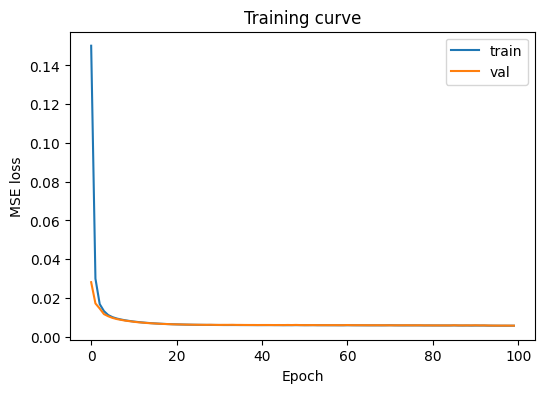

In [13]:
# plot training curves
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training curve")
plt.legend()
plt.show()

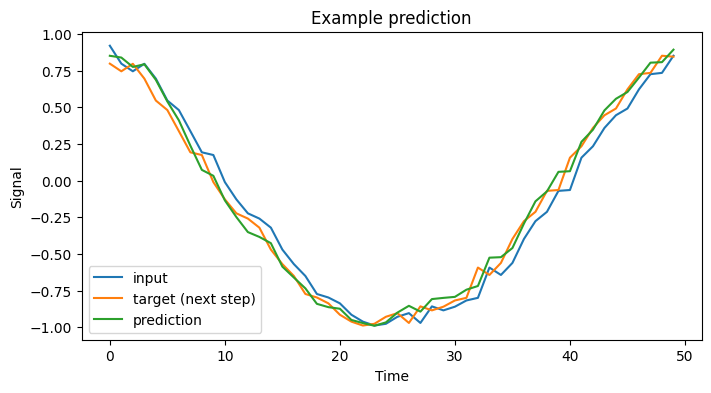

In [14]:
# look at predictions
model.eval()
xb, yb = next(iter(val_loader))
xb, yb = xb.to(device), yb.to(device)

with torch.no_grad():
    preds, _ = model(xb)

xb_np = xb[0].cpu().numpy().squeeze()
yb_np = yb[0].cpu().numpy().squeeze()
pred_np = preds[0].cpu().numpy().squeeze()

plt.figure(figsize=(8, 4))
plt.plot(xb_np, label="input")
plt.plot(yb_np, label="target (next step)")
plt.plot(pred_np, label="prediction")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("Example prediction")
plt.legend()
plt.show()

In [16]:
# build full recurrent blow matrix for visualization
def extract_block_recurrent_matrix(model):
    """
    Returns one big block matrix W of shape:
    (num_modules * hidden_size, num_modules * hidden_size)

    Block (i, j):
        - self weight if i == j
        - cross weight j -> i if i != j
    """
    num_modules = model.num_modules
    hidden_size = model.hidden_size

    blocks = []
    for i in range(num_modules):
        row_blocks = []
        for j in range(num_modules):
            if i == j:
                w = model.self_linears[i].weight.detach().cpu()
            else:
                w = model.cross_linears[i][j].weight.detach().cpu()
            row_blocks.append(w)
        blocks.append(torch.cat(row_blocks, dim=1))

    W = torch.cat(blocks, dim=0)
    return W.numpy()


W = extract_block_recurrent_matrix(model)
print("Block recurrent matrix shape:", W.shape)

Block recurrent matrix shape: (48, 48)


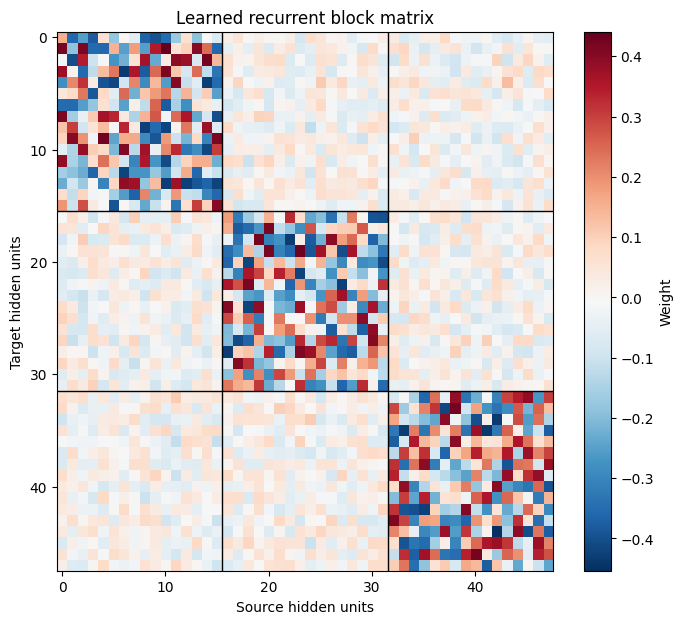

In [21]:
# plot learned block connectivity
plt.figure(figsize=(8, 7))
plt.imshow(W, aspect="auto", cmap="RdBu_r")
plt.colorbar(label="Weight")

for k in range(1, num_modules):
    plt.axhline(k * hidden_size - 0.5, color="black", linewidth=1)
    plt.axvline(k * hidden_size - 0.5, color="black", linewidth=1)

plt.title("Learned recurrent block matrix")
plt.xlabel("Source hidden units")
plt.ylabel("Target hidden units")
plt.show()

Block Frobenius norms:
[[4.00601959 0.79877722 0.80181009]
 [0.86439389 3.91188335 0.80686831]
 [0.79819053 0.80441868 4.05728483]]


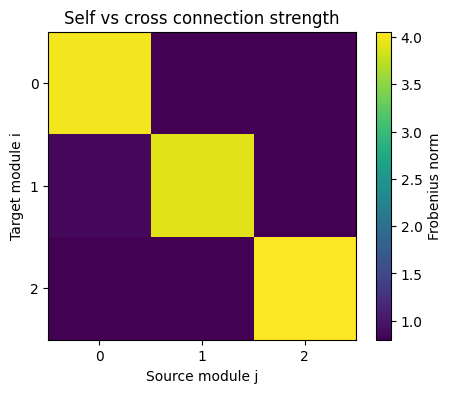

In [22]:
def block_frobenius_norms(model):
    num_modules = model.num_modules
    norms = np.zeros((num_modules, num_modules))

    for i in range(num_modules):
        for j in range(num_modules):
            if i == j:
                w = model.self_linears[i].weight.detach().cpu().numpy()
            else:
                w = model.cross_linears[i][j].weight.detach().cpu().numpy()
            norms[i, j] = np.linalg.norm(w)

    return norms


norms = block_frobenius_norms(model)
print("Block Frobenius norms:")
print(norms)

plt.figure(figsize=(5, 4))
plt.imshow(norms, cmap="viridis")
plt.colorbar(label="Frobenius norm")
plt.title("Self vs cross connection strength")
plt.xlabel("Source module j")
plt.ylabel("Target module i")
plt.xticks(range(num_modules))
plt.yticks(range(num_modules))
plt.show()

- give modules different inputs (sin, cosine, delayed/other freq; target depends on them being combined)
- reduce module capacity (decrease hidden_size)
- predict something more complex
- initialize cross weights larger
- don't feed 3D input to every module. each only has one channel and readout is the combination of them.

First goal is to let the model learn both within-region and between-region connectivity from the task then analyze what kind of structure emerges.
- local recurrent connectivity
- dorsal drives middle drives ventral (mostly feedforward)

Some questions:
- does a directional coupling emerge?
- does one module become earlier/faster and another later/broader?
- do cross-region weights become asymmetric?
- does the model discover a dorsal-to-ventral flow-like organization on its own?

Does this architecture naturally discover longitudinal organization as a useful solution to the task?

Soft architectural bias + learning
- only neighboring coupling 1 <-> 2 <-> 3
- initialize forward directions slightly stronger than backward
- penalize long-range connections
- dorsal module smaller place fields/faster dynamics
- ventral module broader place fields/slower dynamics
- dorsal gets stronger sensory detail vs ventral getting more contextual/coarse info

Task:
- local recurrent structure should matter
- cross-region coordination should matter
- timing/order matters

1. Sequence continuation/replay: give network a short cue and require it to continue a place-cell sequence
2. One-step or multi-step spatial prediction: train the system to predict the next population code along a trajectory
3. denoising/pattern completion plus progression: cue part of trajectory and require network to complete and advance it

Space:
- add distance-dependence (kernels, delays)